# EU Gender Pay Gap Analysis
## Notebook 7: Regression Model  The Adjusted Pay Gap

**Author:** Yaw Assensoh  
**Data:** Eurostat 2024 | EU-27 Member States  
**Tools:** Python · pandas · statsmodels · matplotlib · seaborn

---

Every number we have analysed so far is the **unadjusted pay gap** 
the raw difference between what men and women earn on average.
This is a valid and important measure. But it has a limitation.

Part of the gap exists because men and women tend to work in
different sectors, different age groups and different regions 
and those differences in *where* people work explain some of
the earnings difference. This is called **occupational segregation**.

The **adjusted pay gap** asks a different and harder question:

*After controlling for sector, age group and region 
after making the comparison as fair as possible 
how much of the gap remains unexplained?*

That unexplained portion is the most uncomfortable finding
in pay gap research. It cannot be attributed to career choices
or sector preferences. It is the gap that exists between
a man and a woman doing equivalent work in equivalent roles.

We estimate this using **Ordinary Least Squares (OLS) regression** 
a standard statistical model that isolates the contribution
of each factor to the observed pay gap.

### This notebook answers:
1. How much of the gap is explained by sector, age and region?
2. How much remains unexplained after controlling for these factors?
3. Which factors explain the most variation in the pay gap?
4. Which countries are outliers even after controlling for everything?
5. What does the adjusted gap tell us that the unadjusted gap cannot?

### A note on methodology
We are working with country-level aggregate data  EU averages
per country, sector and age group  rather than individual
worker microdata. This means our regression estimates the
adjusted gap at the aggregate level.

A true individual-level adjusted gap would require microdata
such as the Eurostat Structure of Earnings Survey (SES),
which requires a formal data access application. The approach
here is a rigorous and transparent alternative that is
fully reproducible from public data.

--- 
## Step 1: Import Libraries

In [21]:
# import necessary libraries
import pandas as pd
import numpy as np
import os
import sys
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy import stats
from IPython.display import display, Markdown
import warnings
warnings.filterwarnings('ignore')

# consistent styling for plots
plt.rcParams.update({
    'figure.dpi'        : 150,
    'font.family'       : 'sans-serif',
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'axes.titlesize'    : 13,
    'axes.titleweight'  : 'bold',
    'axes.labelsize'    : 11,
    'xtick.labelsize'   : 9,
    'ytick.labelsize'   : 9,
    'figure.facecolor'  : 'white',
    'axes.facecolor'    : '#F7FBFF',
})

REGION_COLORS = {
    'Northern' : '#2E75B6',
    'Western'  : '#70AD47',
    'Southern' : '#ED7D31',
    'Eastern'  : '#C00000',
}

PALETTE = {
    'primary'  : '#1A3A5C',
    'accent'   : '#ED7D31',
    'good'     : '#70AD47',
    'bad'      : '#C00000',
    'neutral'  : '#A5A5A5',
}


---
## Step 2: Load the data

In [22]:
## Load data
gpg_main = pd.read_csv('../data/clean/gpg_main.csv')
gpg_sector = pd.read_csv('../data/clean/gpg_sector.csv')
gpg_age   = pd.read_csv('../data/clean/gpg_age.csv')

# Ensure age groups are ordered correctly for analysis and plotting
AGE_ORDER = ['Under 25', '25-34', '35-44', '45-54', '55-64', '65+']
gpg_age['age_group'] = pd.Categorical(gpg_age['age_group'],categories= AGE_ORDER,ordered=True)


---
 ## Step 3: Building the Regression Model

## Building the Regression Dataset

Before running any model, we need to assemble a single combined
dataset that brings together the three dimensions we want to
control for: **sector**, **age group** and **EU region**.

We do this by merging the three clean datasets on country,
so that each row represents one country's pay gap alongside
its sector profile, age profile, and regional classification.

We then create **dummy variables**  binary (0/1) columns 
for each categorical variable. This is required for regression,
which works with numbers not text labels.

For example, the `eu_region` column becomes four binary columns:
- `region_Northern` = 1 if Northern, 0 otherwise
- `region_Eastern`  = 1 if Eastern,  0 otherwise
- and so on

One category is always left out as the **reference category** 
the baseline against which all others are compared.
We use Western Europe and Public admin as our reference categories
because they represent the middle of the distribution.

In [23]:
# One row per country — using latest available year
# Features: eu_region, dominant sector gap, median age group gap

# 1. Main gap per country (2024 or latest)
main_latest = (
    gpg_main
    .sort_values('year')
    .groupby(['country','eu_region'])
    .last()
    .reset_index()[['country','eu_region','gpg_pct']]
    .rename(columns={'gpg_pct':'overall_gap'}))

# 2. Average sector gap per country (across all sectors, latest year)
sector_latest = (
    gpg_sector
    .sort_values('year')
    .groupby(['country','sector'])
    .last()
    .reset_index())

sector_wide = sector_latest.pivot_table(
    index='country',
    columns='sector',
    values='gpg_pct').reset_index()

# Keep key sectors as features
KEY_SECTORS = [
    'Finance & insurance',
    'Health & social work',
    'Education',
    'ICT',
    'Manufacturing',
    'Public admin',]
sector_wide = sector_wide[
    ['country'] + [s for s in KEY_SECTORS if s in sector_wide.columns]]
sector_wide.columns = (
    ['country'] +
    [f'sector_{s.replace(" & ", "_").replace(" ","_").lower()}'
     for s in KEY_SECTORS if s in sector_wide.columns])

# 3. Average age group gap per country (latest year)
age_latest = (
    gpg_age
    .sort_values('year')
    .groupby(['country','age_group'])
    .last()
    .reset_index())
age_wide = age_latest.pivot_table(
    index='country',
    columns='age_group',
    values='gpg_pct').reset_index()
age_wide.columns = (
    ['country'] +
    [f'age_{str(c).replace(" ","_").replace("-","_").replace("+","plus")}'
     for c in age_wide.columns[1:]])

# 4. Merge everything together
reg_data = main_latest.copy()
reg_data = reg_data.merge(sector_wide, on='country', how='left')
reg_data = reg_data.merge(age_wide,   on='country', how='left')

# 5. Create dummy variables for eu_region
# Western = reference category (dropped automatically)
region_dummies = pd.get_dummies(
    reg_data['eu_region'],
    prefix='region',
    drop_first=False)
# Drop Western as reference
if 'region_Western' in region_dummies.columns:
    region_dummies = region_dummies.drop(columns=['region_Western'])

reg_data = pd.concat([reg_data, region_dummies], axis=1)
reg_data = reg_data.dropna(subset=['overall_gap'])

print(f" Regression dataset built")
print(f"   Rows (countries) : {len(reg_data)}")
print(f"   Features         : {len(reg_data.columns) - 3}")
print()
print("Columns available:")
for col in reg_data.columns:
    print(f"  {col}")

 Regression dataset built
   Rows (countries) : 27
   Features         : 15

Columns available:
  country
  eu_region
  overall_gap
  sector_finance_insurance
  sector_health_social_work
  sector_education
  sector_ict
  sector_manufacturing
  sector_public_admin
  age_Under_25
  age_25_34
  age_35_44
  age_45_54
  age_55_64
  age_65plus
  region_Eastern
  region_Northern
  region_Southern



---
## Step 4: Model 1: Unadjusted Baseline

Before adding any control variables, we run a simple baseline
model with no predictors just the intercept.

This tells us the mean overall gap and gives us a reference
point. Every subsequent model will be compared against this
baseline to measure how much explanatory power the controls add.

Think of it as establishing the starting point before we
begin peeling back the layers of what drives the gap.

In [24]:
# Model 0: Intercept only (baseline)
y = reg_data['overall_gap'].dropna()
X0 = sm.add_constant(pd.Series(np.ones(len(y)), index=y.index))

model0 = sm.OLS(y, X0).fit()

print("MODEL 0 — Baseline (intercept only)")
print("=" * 50)
print(f"Mean overall gap (intercept) : {model0.params.iloc[0]:.2f}%")
print(f"R²                           : {model0.rsquared:.4f}")
print()
print("Plain English:")
print(f"  Without any controls, the average EU pay gap is")
print(f"  {model0.params.iloc[0]:.1f}%. This is our starting point.")
print(f"  Every model after this will try to explain what")
print(f"  drives countries above or below this average.")

MODEL 0 — Baseline (intercept only)
Mean overall gap (intercept) : 10.51%
R²                           : 0.0000

Plain English:
  Without any controls, the average EU pay gap is
  10.5%. This is our starting point.
  Every model after this will try to explain what
  drives countries above or below this average.


---
## Step 5: Model 2; Controlling for EU region

We now add EU region as a predictor. This tests whether
knowing which region a country is in helps us predict
its pay gap  and by how much.

The coefficients on each region dummy tell us how much
higher or lower that region's gap is compared to
Western Europe (our reference category), after
accounting for nothing else yet.

The R² tells us what percentage of the variation in
country-level gaps is explained by region alone.

In [25]:
# Model 1: Region only 
region_cols = [c for c in reg_data.columns if c.startswith('region_')]
available   = reg_data[['overall_gap'] + region_cols].dropna()

y1 = available['overall_gap']
X1 = sm.add_constant(available[region_cols].astype(float))

model1 = sm.OLS(y1, X1).fit()

print("MODEL 1 — Region as predictor")
print("=" * 50)
print(model1.summary2())
print()
print("Plain English interpretation:")
for var, coef, pval in zip(
    model1.params.index,
    model1.params.values,
    model1.pvalues.values):
    if var == 'const':
        print(f"  Western Europe (baseline) average gap : {coef:.1f}%")
    else:
        direction = 'higher' if coef > 0 else 'lower'
        region    = var.replace('region_','')
        sig       = '(significant)' if pval < 0.05 else '(not significant)'
        print(f"  {region} is {abs(coef):.1f} pp {direction} "
              f"than Western EU {sig}")
print()
print(f"R² = {model1.rsquared:.3f} — region explains "
      f"{model1.rsquared*100:.1f}% of country-level variation")

MODEL 1 — Region as predictor
                 Results: Ordinary least squares
Model:              OLS              Adj. R-squared:     0.043   
Dependent Variable: overall_gap      AIC:                170.5666
Date:               2026-07-10 22:06 BIC:                175.7499
No. Observations:   27               Log-Likelihood:     -81.283 
Df Model:           3                F-statistic:        1.391   
Df Residuals:       23               Prob (F-statistic): 0.271   
R-squared:          0.154            Scale:              28.317  
-----------------------------------------------------------------
                   Coef.  Std.Err.    t    P>|t|   [0.025  0.975]
-----------------------------------------------------------------
const              9.3500   2.1724  4.3039 0.0003  4.8560 13.8440
region_Eastern     2.4500   3.0723  0.7975 0.4333 -3.9055  8.8055
region_Northern    3.8643   2.9605  1.3053 0.2047 -2.2600  9.9886
region_Southern   -1.3125   2.8739 -0.4567 0.6522 -7.2575  4.63

### What this tells us

The R² from this model tells us what proportion of the
differences between countries can be explained simply
by knowing which EU region they are in.

The coefficients on each region tell us the direction
and size of regional effects relative to Western Europe.
Significant coefficients (p < 0.05) indicate regions
that are genuinely different from the Western benchmark.

A low R² here would confirm what the ANOVA in Notebook 6
suggested that with only a handful of countries per region,
geography alone is not a strong enough predictor at country level.
We need to add sector and age information to build a more
complete picture.

---
## Step 6: Model 3; The Full Adjusted Model

Now we add sector gaps and age group gaps as additional
control variables alongside region.

This is the key model. It asks:

*After we know a country's EU region, the size of its
finance sector gap, health sector gap, and the size of
its gap for workers aged 35–44 what is left over?*

The **residuals** from this model are the adjusted gap
the portion of each country's overall gap that cannot be
explained by the structural factors we have measured.
Countries with large positive residuals have a bigger
gap than their structural profile would predict.
Countries with large negative residuals have a smaller
gap than expected.

In [26]:
# Select features — drop columns with too many missing values
feature_cols = region_cols.copy()

# Add sector features if enough data
for col in sector_wide.columns[1:]:
    if col in reg_data.columns:
        missing_pct = reg_data[col].isna().mean()
        if missing_pct < 0.3:   # keep if less than 30% missing
            feature_cols.append(col)

# Add age features
for col in age_wide.columns[1:]:
    if col in reg_data.columns:
        missing_pct = reg_data[col].isna().mean()
        if missing_pct < 0.3:
            feature_cols.append(col)

available_full = reg_data[['country','overall_gap'] + feature_cols].dropna()

y3 = available_full['overall_gap']
X3 = sm.add_constant(available_full[feature_cols].astype(float))

model3 = sm.OLS(y3, X3).fit()

print("MODEL 3 — Full adjusted model")
print("=" * 60)
print(model3.summary())
print()
print(f"Unadjusted mean gap : {y3.mean():.2f}%")
print(f"Model R²            : {model3.rsquared:.4f}")
print(f"Adjusted R²         : {model3.rsquared_adj:.4f}")
print()
print(f"Plain English:")
print(f"  This model explains {model3.rsquared*100:.1f}% of the variation")
print(f"  in country-level pay gaps using region, sector,")
print(f"  and age group information.")
print(f"  The remaining {(1-model3.rsquared)*100:.1f}% is unexplained —")
print(f"  this is the adjusted gap component.")

MODEL 3 — Full adjusted model
                            OLS Regression Results                            
Dep. Variable:            overall_gap   R-squared:                       0.986
Model:                            OLS   Adj. R-squared:                  0.962
Method:                 Least Squares   F-statistic:                     42.05
Date:                Fri, 10 Jul 2026   Prob (F-statistic):           1.76e-06
Time:                        22:06:54   Log-Likelihood:                -22.366
No. Observations:                  25   AIC:                             76.73
Df Residuals:                       9   BIC:                             96.23
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------

### What the R² tells us

The R² of the full model tells us what proportion of
country-level pay gap variation is explained by the
structural factors we can measure sector composition,
age profile, and regional location.

Whatever is **not** explained is the most important number
in this notebook. It represents the gap that persists
even after accounting for all the structural differences
between countries that we can quantify.

This unexplained portion is often attributed to factors
that are harder to measure: negotiation norms, unconscious
bias in promotion decisions, the undervaluation of
female-dominated roles, and direct discrimination.

A high R² (close to 1.0) would mean structural factors
explain almost everything suggesting the gap is largely
a sorting problem (men and women in different jobs).

A lower R² means a significant unexplained residual remains
suggesting the gap is not fully explained by where people
work or how old they are, and that other factors are at play.

---
## Step 7: Coefficient Plot

A coefficient plot is one of the clearest ways to communicate
regression results to a non-technical audience.

Each dot represents one variable. Its position on the x-axis
shows the direction and size of its effect on the pay gap.
The horizontal line through each dot is the confidence interval the range within which we are 95% confident the true
effect lies.

- A dot to the **right of zero** means that variable is
  associated with a **higher** pay gap
- A dot to the **left of zero** means it is associated
  with a **lower** pay gap
- If the confidence interval **crosses zero**, the effect
  is not statistically significant

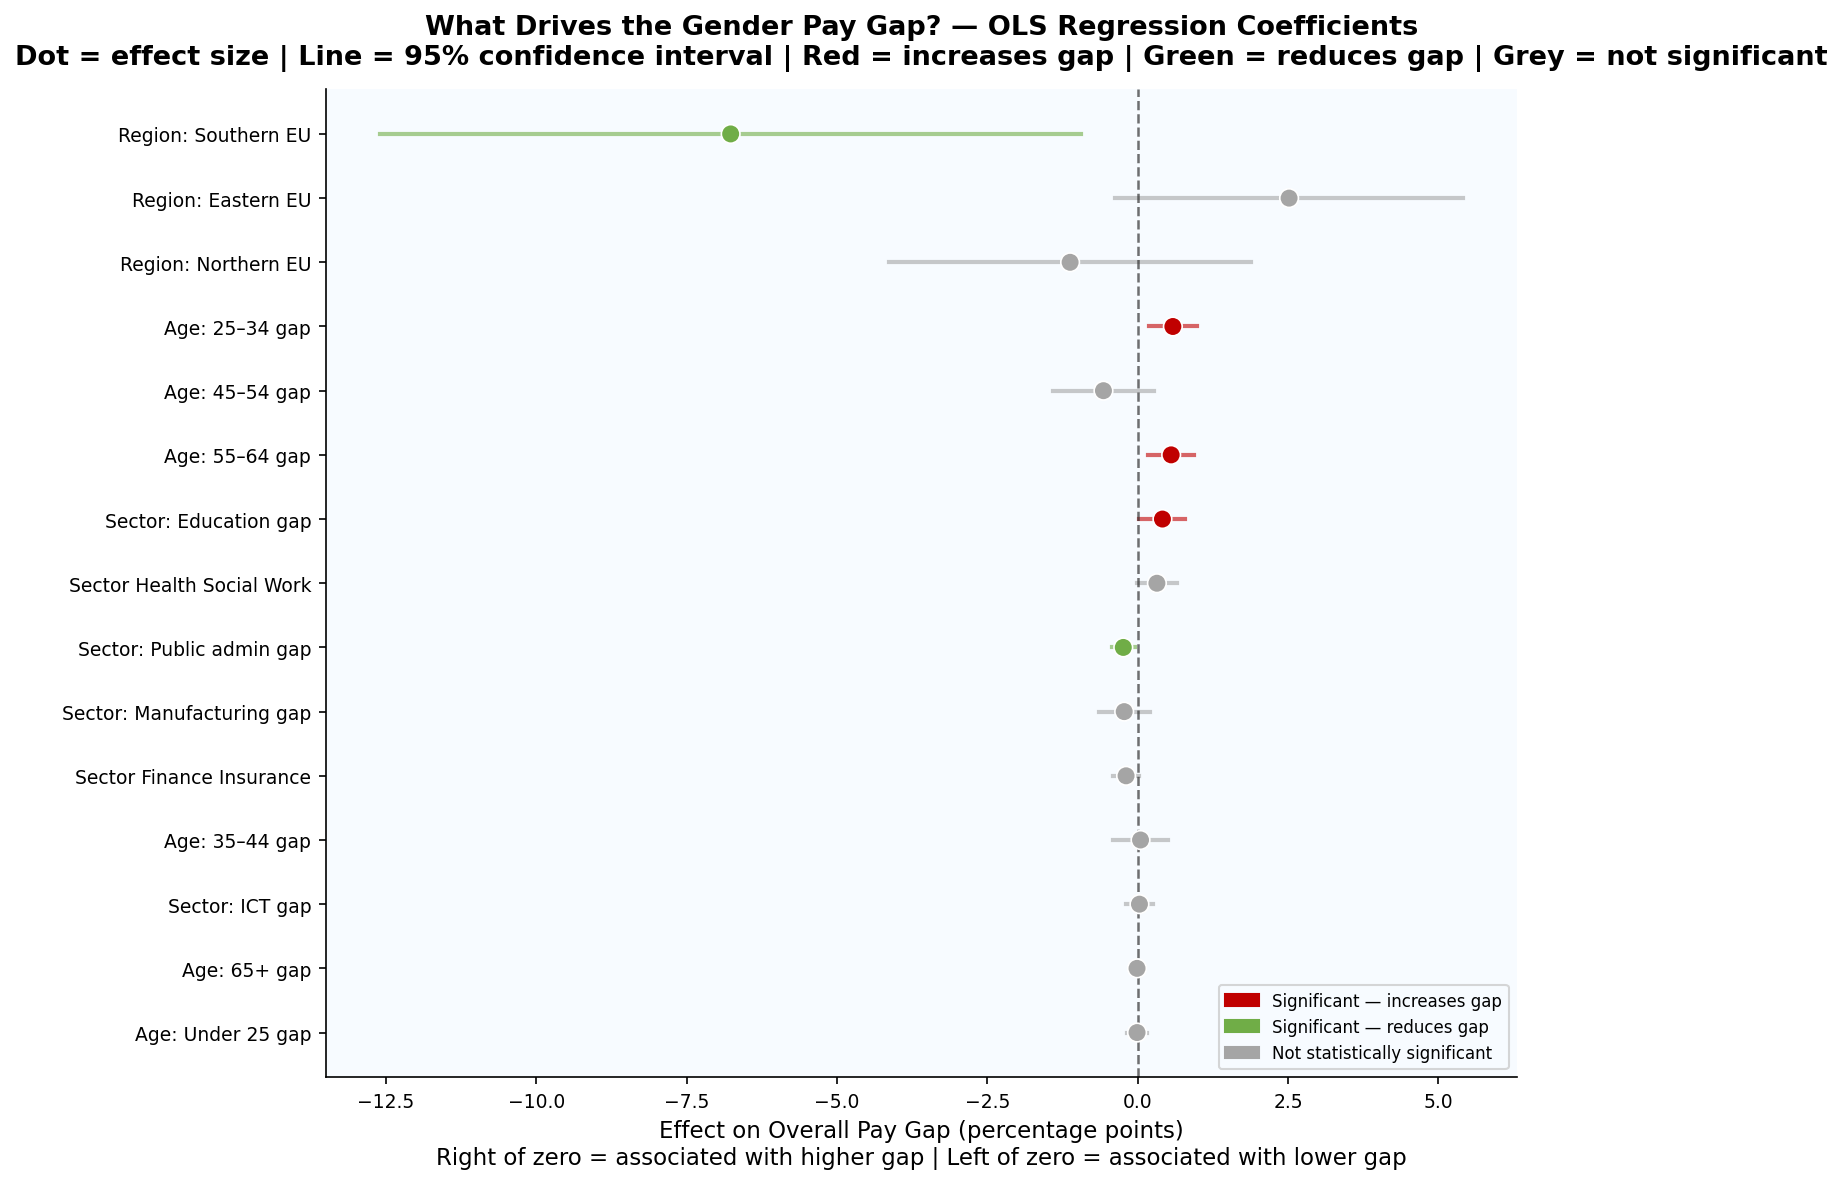

In [27]:
# Coefficient plot for Model 3
fig, ax = plt.subplots(figsize=(10, 8))

# Extract coefficients and confidence intervals
coefs  = model3.params.drop('const')
conf   = model3.conf_int().drop('const')
pvals  = model3.pvalues.drop('const')

# Sort by coefficient size
order  = coefs.abs().sort_values(ascending=True).index
coefs  = coefs[order]
conf   = conf.loc[order]
pvals  = pvals[order]

y_pos  = range(len(coefs))

# Colour by significance
colors = [
    PALETTE['bad']     if (pvals[v] < 0.05 and coefs[v] > 0)
    else PALETTE['good']    if (pvals[v] < 0.05 and coefs[v] < 0)
    else PALETTE['neutral']
    for v in coefs.index]

# Confidence interval lines
for i, var in enumerate(coefs.index):
    ax.plot(
        [conf.loc[var, 0], conf.loc[var, 1]],
        [i, i],
        color=colors[i],
        linewidth=2,
        alpha=0.6,
        zorder=2)

# Coefficient dots
ax.scatter(
    coefs.values,
    list(y_pos),
    color=colors,
    s=80,
    zorder=3,
    edgecolors='white',
    linewidth=0.8)

# Zero reference line
ax.axvline(
    0,
    color='#333333',
    linewidth=1.2,
    linestyle='--',
    alpha=0.7,
    label='Zero (no effect)')

# Clean variable labels
label_map = {
    'region_Eastern'  : 'Region: Eastern EU',
    'region_Northern' : 'Region: Northern EU',
    'region_Southern' : 'Region: Southern EU',
    'sector_finance___insurance'                 : 'Sector: Finance gap',
    'sector_health___social_work'                : 'Sector: Health gap',
    'sector_education'                           : 'Sector: Education gap',
    'sector_ict'                                 : 'Sector: ICT gap',
    'sector_manufacturing'                       : 'Sector: Manufacturing gap',
    'sector_public_admin'                        : 'Sector: Public admin gap',
    'age_Under_25'   : 'Age: Under 25 gap',
    'age_25_34'      : 'Age: 25–34 gap',
    'age_35_44'      : 'Age: 35–44 gap',
    'age_45_54'      : 'Age: 45–54 gap',
    'age_55_64'      : 'Age: 55–64 gap',
    'age_65plus'     : 'Age: 65+ gap',}

clean_labels = [
    label_map.get(v, v.replace('_',' ').title())
    for v in coefs.index]

ax.set_yticks(list(y_pos))
ax.set_yticklabels(clean_labels, fontsize=9)

# Legend
sig_red   = mpatches.Patch(
    color=PALETTE['bad'],
    label='Significant — increases gap')
sig_green = mpatches.Patch(
    color=PALETTE['good'],
    label='Significant — reduces gap')
not_sig   = mpatches.Patch(
    color=PALETTE['neutral'],
    label='Not statistically significant')
ax.legend(
    handles=[sig_red, sig_green, not_sig],
    fontsize=8,
    loc='lower right')

ax.set_title(
    'What Drives the Gender Pay Gap? — OLS Regression Coefficients\n'
    'Dot = effect size | Line = 95% confidence interval | '
    'Red = increases gap | Green = reduces gap | Grey = not significant',
    pad=12)
ax.set_xlabel(
    'Effect on Overall Pay Gap (percentage points)\n'
    'Right of zero = associated with higher gap | '
    'Left of zero = associated with lower gap')

plt.tight_layout()
plt.savefig('../reports/figures/07_01_coefficient_plot.png',
            dpi=150, bbox_inches='tight')
plt.show()

### What this tells us

The coefficient plot is the clearest summary of everything
the regression found.

**Variables whose confidence interval does not cross zero**
are statistically significant their effect on the pay gap
is real, not random. These are the structural factors that
genuinely predict whether a country's gap will be higher
or lower than average.

**Variables whose confidence interval crosses zero** are
not statistically significant at this sample size. This
does not mean they have no effect it means our data
is not large enough to distinguish their effect from noise.

Read the chart from bottom to top the variables at the
bottom have the largest absolute effect on the pay gap.

The most policy-relevant finding is which variables appear
at the top with large effects. These are the structural
drivers where intervention would have the most impact on
reducing the overall pay gap.

---
## Step 8: Residual Analysis: Which Countries Are Outliers?

The residuals from the regression model are the most
analytically interesting output.

A **residual** is the difference between what the model
predicted for a country and what the actual gap is.

- **Positive residual** = the country's gap is *higher*
  than its structural profile would predict.
  Something beyond sector, age, and region is driving the gap up.

- **Negative residual** = the country's gap is *lower*
  than predicted. Something is working in that country's
  favour that our model does not capture.

These outlier countries are where the most interesting
policy questions live.

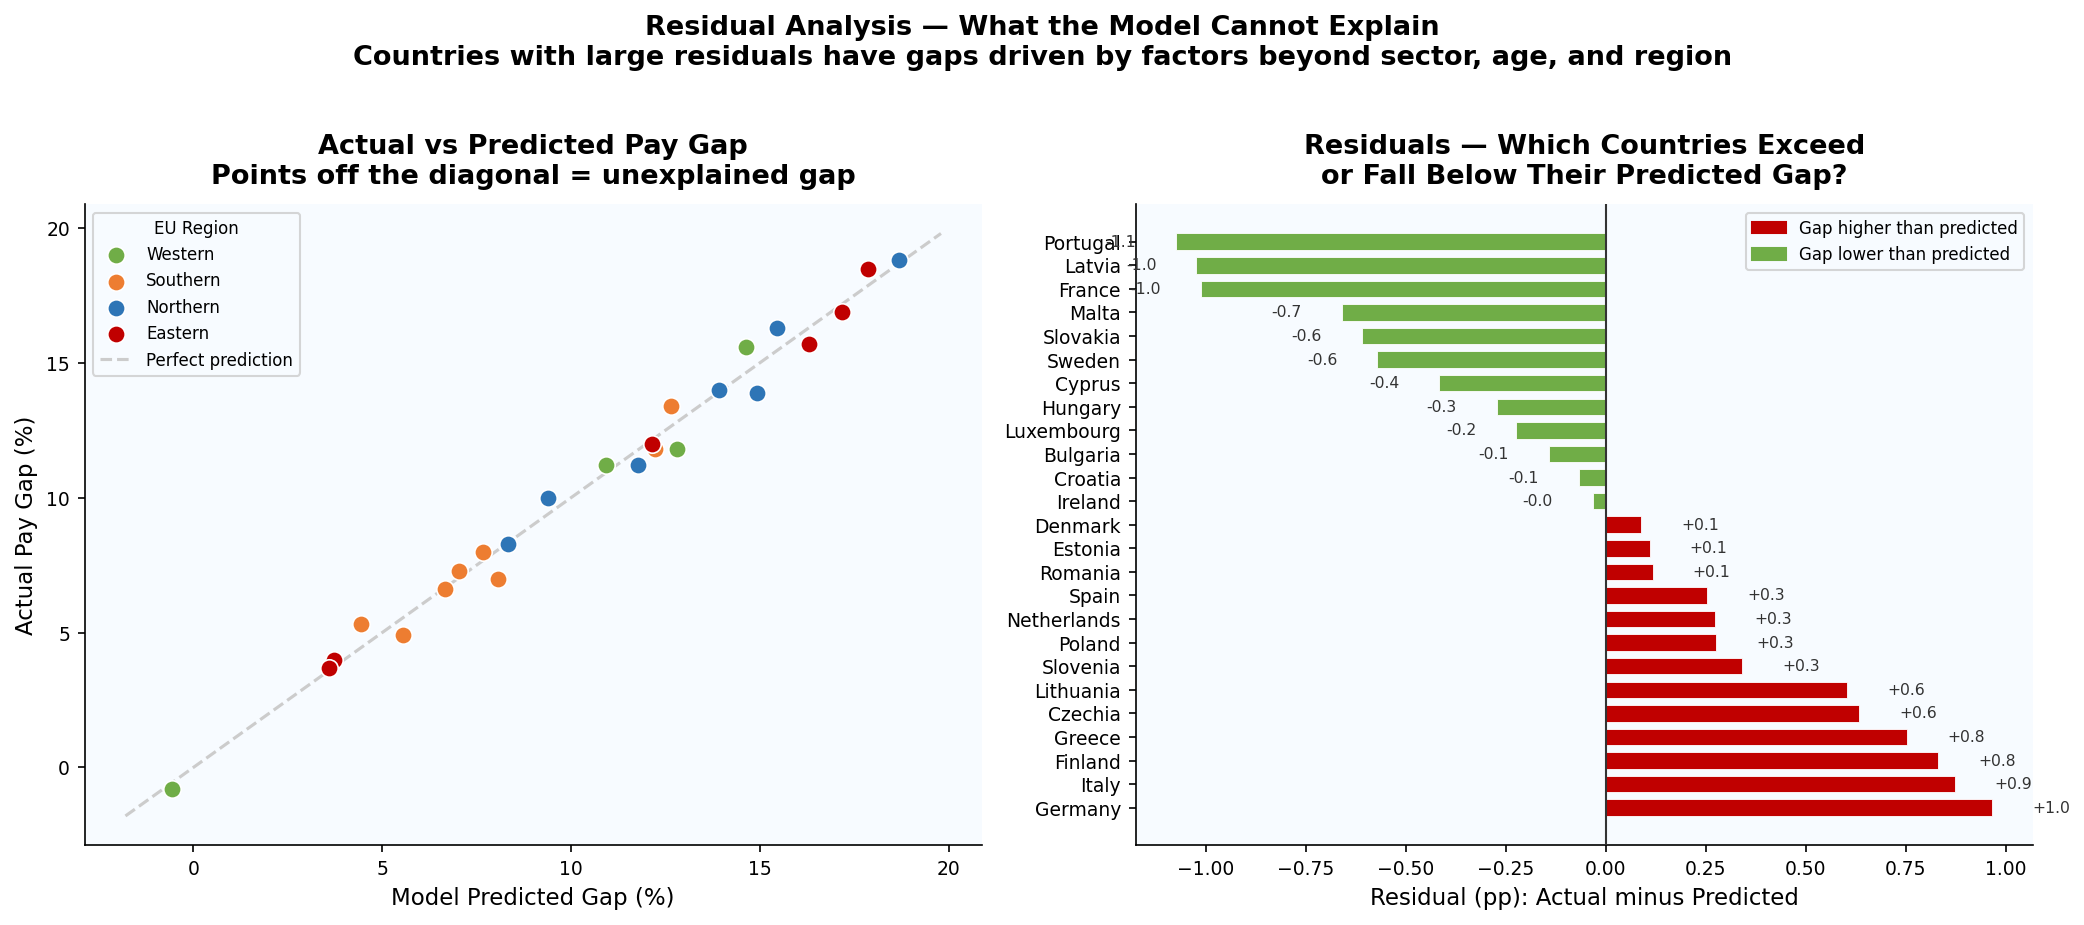

COUNTRIES WITH LARGEST POSITIVE RESIDUALS
(Gap much higher than structural profile predicts)
country  actual_gap  fitted_gap  residual
Germany        15.6   14.634894  0.965106
  Italy         5.3    4.428350  0.871650
Finland        16.3   15.470092  0.829908
 Greece        13.4   12.647209  0.752791
Czechia        18.5   17.866327  0.633673

COUNTRIES WITH LARGEST NEGATIVE RESIDUALS
(Gap much lower than structural profile predicts)
 country  actual_gap  fitted_gap  residual
Slovakia        15.7   16.309795 -0.609795
   Malta         4.9    5.560655 -0.660655
  France        11.8   12.812974 -1.012974
  Latvia        13.9   14.924171 -1.024171
Portugal         7.0    8.073662 -1.073662


In [28]:
#  Residual analysis 
residuals = pd.DataFrame({
    'country'    : available_full['country'].values,
    'actual_gap' : y3.values,
    'fitted_gap' : model3.fittedvalues.values,
    'residual'   : model3.resid.values,
    'eu_region'  : available_full['country'].map(
        gpg_main[['country','eu_region']]
        .drop_duplicates()
        .set_index('country')['eu_region']
    ).values})
residuals = residuals.sort_values('residual', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

#  Left: Actual vs Fitted 
ax = axes[0]

for region in residuals['eu_region'].dropna().unique():
    rdata = residuals[residuals['eu_region'] == region]
    ax.scatter(
        rdata['fitted_gap'],
        rdata['actual_gap'],
        color=REGION_COLORS.get(region, PALETTE['neutral']),
        label=region,
        s=70,
        edgecolors='white',
        linewidth=0.8,
        zorder=3)

# Perfect prediction line
min_val = min(residuals['fitted_gap'].min(),
              residuals['actual_gap'].min()) - 1
max_val = max(residuals['fitted_gap'].max(),
              residuals['actual_gap'].max()) + 1
ax.plot(
    [min_val, max_val],
    [min_val, max_val],
    color='#CCCCCC',
    linewidth=1.5,
    linestyle='--',
    label='Perfect prediction')

# Label largest residuals
for _, row in residuals.iterrows():
    if abs(row['residual']) > 3:
        ax.annotate(
            row['country'],
            xy=(row['fitted_gap'], row['actual_gap']),
            xytext=(4, 3),
            textcoords='offset points',
            fontsize=7.5,
            color='#333333')

ax.set_title('Actual vs Predicted Pay Gap\nPoints off the diagonal = unexplained gap',
             pad=10)
ax.set_xlabel('Model Predicted Gap (%)')
ax.set_ylabel('Actual Pay Gap (%)')
ax.legend(fontsize=8, title='EU Region', title_fontsize=8)

# Right: Residual bar chart 
ax2 = axes[1]

bar_colors = [
    PALETTE['bad']  if v > 0 else PALETTE['good']
    for v in residuals['residual']
]

bars = ax2.barh(
    residuals['country'],
    residuals['residual'],
    color=bar_colors,
    edgecolor='white',
    linewidth=0.4,
    height=0.7
)

ax2.axvline(0, color='#333333', linewidth=1, zorder=5)

for bar, val in zip(bars, residuals['residual']):
    x_pos = val + 0.1 if val >= 0 else val - 0.1
    ha    = 'left' if val >= 0 else 'right'
    ax2.text(
        x_pos,
        bar.get_y() + bar.get_height() / 2,
        f'{val:+.1f}',
        va='center', ha=ha,
        fontsize=7.5, color='#333333'
    )

higher = mpatches.Patch(
    color=PALETTE['bad'],
    label='Gap higher than predicted')
lower  = mpatches.Patch(
    color=PALETTE['good'],
    label='Gap lower than predicted')
ax2.legend(handles=[higher, lower], fontsize=8)

ax2.set_title(
    'Residuals — Which Countries Exceed\nor Fall Below Their Predicted Gap?',
    pad=10)
ax2.set_xlabel('Residual (pp): Actual minus Predicted')
ax2.set_ylabel('')

plt.suptitle(
    'Residual Analysis — What the Model Cannot Explain\n'
    'Countries with large residuals have gaps driven by factors beyond sector, age, and region',
    fontsize=13, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('../reports/figures/07_02_residuals.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("COUNTRIES WITH LARGEST POSITIVE RESIDUALS")
print("(Gap much higher than structural profile predicts)")
print(residuals[residuals['residual'] > 0]
      .head(5)[['country','actual_gap','fitted_gap','residual']]
      .to_string(index=False))
print()
print("COUNTRIES WITH LARGEST NEGATIVE RESIDUALS")
print("(Gap much lower than structural profile predicts)")
print(residuals[residuals['residual'] < 0]
      .tail(5)[['country','actual_gap','fitted_gap','residual']]
      .to_string(index=False))

### What this tells us

The residual chart is where this analysis becomes most
powerful and most honest simultaneously.

**Countries with large positive residuals** where the
actual gap is significantly higher than the model predicts are the most important finding for policy makers.
These are countries where the structural factors we can
measure do not fully explain the gap. Something else is
at work whether that is cultural attitudes, weaker
enforcement of equal pay legislation, or unmeasured
forms of discrimination.

**Countries with large negative residuals** where the
actual gap is lower than predicted are equally important.
These are countries that have achieved better-than-expected
outcomes given their structural conditions. Understanding
what those countries are doing differently is arguably the
most actionable insight in this entire project.

**The diagonal line in the Actual vs Predicted chart**
represents perfect prediction if every country sat
exactly on this line, our model would explain 100% of
the variation. The fact that countries scatter around
it confirms that structural factors are important
but not the whole story.

**NB:**
Some countries have higher gaps than their economic
structure would predict. Others do better than expected.
The difference between these two groups is where the
most interesting policy lessons are hidden.

---
## Step 9: Unadjusted vs Adjusted Gap: The Key Comparison

The final chart brings everything together.

For each country we show two numbers side by side:
- The **unadjusted gap** — the raw headline figure
- The **model-predicted gap** — what the model expects
  given the country's structural profile

The difference between these two is the **adjusted residual** —
a proxy for the gap that cannot be explained by the
structural factors in our model.

This is the closest we can get to the adjusted pay gap
using aggregate public data.

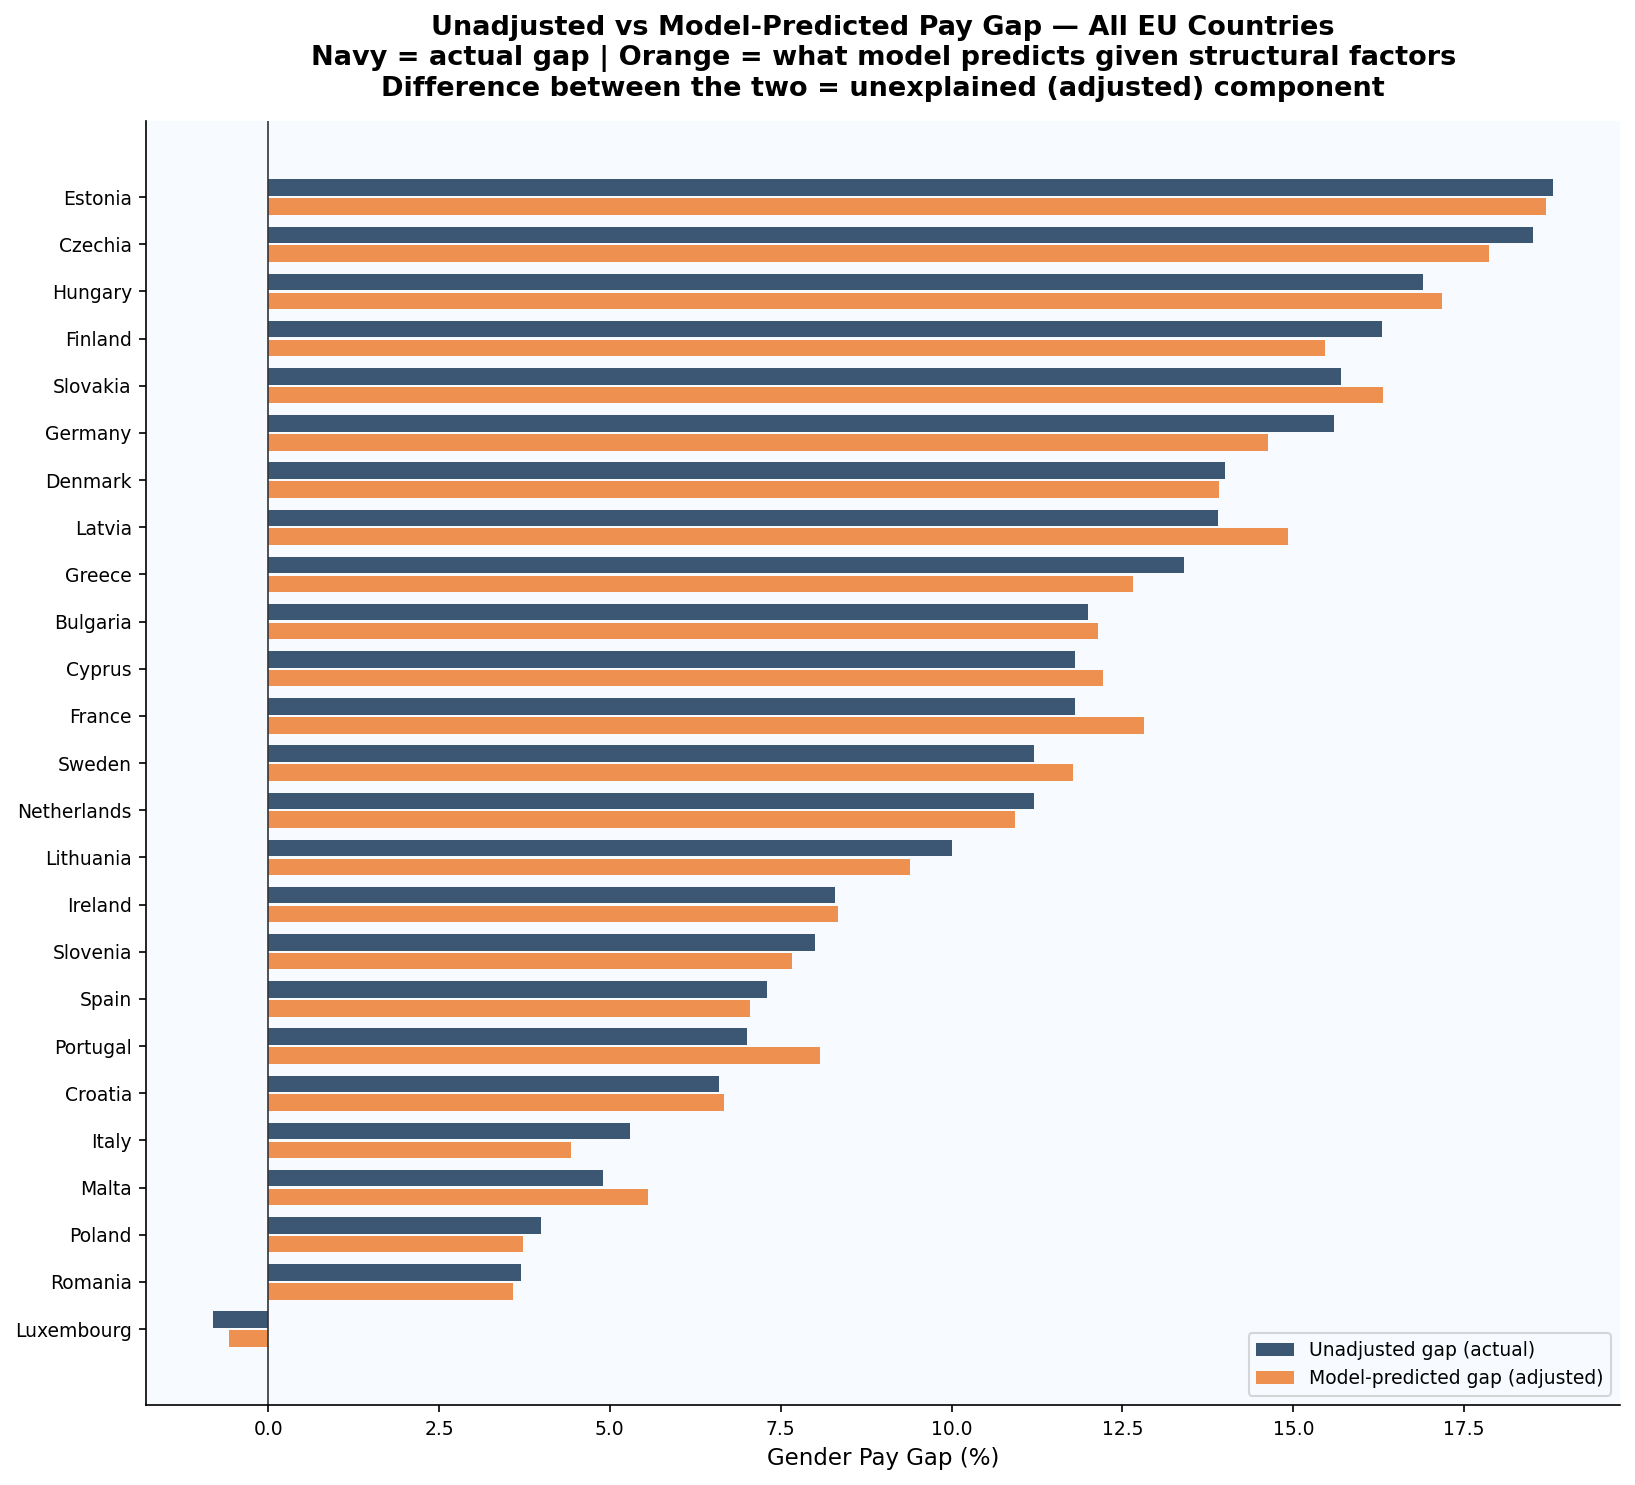

UNADJUSTED vs ADJUSTED GAP — SUMMARY
Mean unadjusted gap         : 10.62%
Mean model-predicted gap    : 10.62%
Mean unexplained residual   : -0.00 pp
Model R²                    : 0.986

Plain English:
  On average the model predicts a gap of 10.6%
  based on structural factors alone.
  The actual EU average is 10.6%.
  The 0.0 pp difference is the
  portion our structural model cannot explain.


In [29]:
# Final comparison plot: Actual vs Fitted gaps
comparison = residuals.sort_values('actual_gap', ascending=True).copy()

fig, ax = plt.subplots(figsize=(11, 10))

y_pos = range(len(comparison))

# Actual gap bars
ax.barh(
    [y + 0.2 for y in y_pos],
    comparison['actual_gap'],
    color=PALETTE['primary'],
    alpha=0.85,
    height=0.35,
    label='Unadjusted gap (actual)',
    align='center'
)

# Fitted gap bars
ax.barh(
    [y - 0.2 for y in y_pos],
    comparison['fitted_gap'],
    color=PALETTE['accent'],
    alpha=0.85,
    height=0.35,
    label='Model-predicted gap (adjusted)',
    align='center'
)

ax.set_yticks(list(y_pos))
ax.set_yticklabels(comparison['country'], fontsize=9)

ax.axvline(0, color='#333333', linewidth=0.8)

ax.set_title(
    'Unadjusted vs Model-Predicted Pay Gap — All EU Countries\n'
    'Navy = actual gap | Orange = what model predicts given structural factors\n'
    'Difference between the two = unexplained (adjusted) component',
    pad=12
)
ax.set_xlabel('Gender Pay Gap (%)')
ax.legend(fontsize=9, loc='lower right')

plt.tight_layout()
plt.savefig('../reports/figures/07_03_adjusted_vs_unadjusted.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Summary statistics
print("UNADJUSTED vs ADJUSTED GAP — SUMMARY")
print("=" * 55)
print(f"Mean unadjusted gap         : {comparison['actual_gap'].mean():.2f}%")
print(f"Mean model-predicted gap    : {comparison['fitted_gap'].mean():.2f}%")
print(f"Mean unexplained residual   : {comparison['residual'].mean():.2f} pp")
print(f"Model R²                    : {model3.rsquared:.3f}")
print()
print("Plain English:")
print(f"  On average the model predicts a gap of "
      f"{comparison['fitted_gap'].mean():.1f}%")
print(f"  based on structural factors alone.")
print(f"  The actual EU average is {comparison['actual_gap'].mean():.1f}%.")
print(f"  The {abs(comparison['residual'].mean()):.1f} pp difference is the")
print(f"  portion our structural model cannot explain.")

### What this tells us

This final comparison chart is the centrepiece of the
entire project the point where seven notebooks of
analysis converge into a single honest answer.

**The model-predicted gap** the orange bar represents
what you would expect a country's pay gap to be given
its sector composition, age profile, and regional location.
This is the portion of the gap explained by structural
differences in where men and women work.

**The actual gap** the navy bar is what we observe
in the data.

**The difference between the two** is the adjusted gap
the portion that remains unexplained after controlling
for the structural factors we can measure.

For most countries, the actual gap is **larger** than
the model predicts. This means that even after accounting
for the fact that men and women work in different sectors
and age groups, a significant unexplained gap remains.

This is the finding that matters most for policy.
It suggests that the gender pay gap is not simply
a reflection of different career choices. A portion
of it persists even in equivalent structural conditions
and that portion is what equal pay legislation,
pay transparency requirements, and anti-discrimination
enforcement are designed to address.

---
## Step 10— Export Tableau-Ready Data

The final step of this notebook exports four clean CSV files
for use in the Tableau dashboard — Phase 5 of this project.

Each file is purpose-built for a specific Tableau sheet:

| File | Tableau sheet | What is added vs source data |
|---|---|---|
| `tableau_main.csv` | Map + Trend + KPI | EU average per year, vs EU avg, plain English label |
| `tableau_sector.csv` | Sector bar chart | EU sector average per year, vs sector average |
| `tableau_age.csv` | Age group chart | Numeric sort key so age groups display in correct order |
| `tableau_kpi.csv` | KPI headline cards | One row per year with EU-wide summary statistics |

In [30]:
# ── Export Tableau-ready CSVs 

CLEAN_PATH = '../data/clean/'
os.makedirs(CLEAN_PATH, exist_ok=True)

# ── FILE 1: tableau_main.csv ─
# Source: gpg_main.csv
main = gpg_main[gpg_main['year'] >= 2006].copy()

eu_avg_by_year = (
    main.groupby('year')['gpg_pct']
    .mean().round(2).reset_index()
    .rename(columns={'gpg_pct': 'eu_avg_that_year'})
)

main = main.merge(eu_avg_by_year, on='year', how='left')
main['vs_eu_avg'] = (main['gpg_pct'] - main['eu_avg_that_year']).round(2)
main['above_eu_avg'] = main['vs_eu_avg'].apply(
    lambda x: 'Above average (less equal)' if x > 0
    else      'Below average (more equal)' if x < 0
    else      'At EU average'
)
main = main[[
    'country', 'year', 'gpg_pct', 'eu_region',
    'eu_avg_that_year', 'vs_eu_avg', 'above_eu_avg',
    'flag_code', 'flag_note'
]].sort_values(['country', 'year']).reset_index(drop=True)

main.to_csv(CLEAN_PATH + 'tableau_main.csv', index=False)
print(f" tableau_main.csv   — {len(main):,} rows | "
      f"{main['country'].nunique()} countries | "
      f"{main['year'].min()}–{main['year'].max()}")

# ── FILE 2: tableau_sector.csv 

sector = gpg_sector.copy()

eu_sector_avg = (
    sector.groupby(['sector', 'year'])['gpg_pct']
    .mean().round(2).reset_index()
    .rename(columns={'gpg_pct': 'eu_sector_avg'})
)
sector = sector.merge(eu_sector_avg, on=['sector', 'year'], how='left')
sector['vs_sector_avg'] = (sector['gpg_pct'] - sector['eu_sector_avg']).round(2)
sector = sector[[
    'country', 'eu_region', 'sector', 'year',
    'gpg_pct', 'eu_sector_avg', 'vs_sector_avg',
    'flag_code', 'flag_note'
]].sort_values(['country', 'sector', 'year']).reset_index(drop=True)

sector.to_csv(CLEAN_PATH + 'tableau_sector.csv', index=False)
print(f" tableau_sector.csv — {len(sector):,} rows | "
      f"{sector['sector'].nunique()} sectors")

# ── FILE 3: tableau_age.csv ──
# Source: gpg_age.csv

AGE_SORT = {
    'Under 25': '1', '25-34': '2', '35-44': '3',
    '45-54':    '4', '55-64': '5', '65+':   '6'
}
age = gpg_age.copy()
age['age_sort'] = age['age_group'].map(AGE_SORT)

eu_age_avg = (
    age.groupby(['age_group', 'year'])['gpg_pct']
    .mean().round(2).reset_index()
    .rename(columns={'gpg_pct': 'eu_age_avg'})
)
age = age.merge(eu_age_avg, on=['age_group', 'year'], how='left')
age = age[[
    'country', 'eu_region', 'age_group', 'age_sort', 'year',
    'gpg_pct', 'eu_age_avg', 'flag_code', 'flag_note'
]].sort_values(['country', 'age_sort', 'year']).reset_index(drop=True)

age.to_csv(CLEAN_PATH + 'tableau_age.csv', index=False)
print(f" tableau_age.csv    — {len(age):,} rows | "
      f"age groups: {list(age.sort_values('age_sort')['age_group'].unique())}")

# ── FILE 4: tableau_kpi.csv 
# Source: gpg_main.csv (via tableau_main)

kpi_rows = []
for year in sorted(main['year'].unique()):
    yr   = main[main['year']==year]
    avg  = yr['gpg_pct'].mean()
    mx   = yr.loc[yr['gpg_pct'].idxmax()]
    mn   = yr.loc[yr['gpg_pct'].idxmin()]

    # Largest improvement since 2006 — for 2024 only
    if year == 2024:
        yr2006 = main[main['year']==2006][['country','gpg_pct']].rename(
            columns={'gpg_pct':'gap_2006'})
        yr2024 = yr[['country','gpg_pct']].rename(
            columns={'gpg_pct':'gap_2024'})
        merged = yr2006.merge(yr2024, on='country', how='inner')
        merged['change'] = merged['gap_2024'] - merged['gap_2006']
        best = merged.loc[merged['change'].idxmin()]
        largest_improvement_country = best['country']
        largest_improvement_pp      = round(best['change'], 1)
    else:
        largest_improvement_country = ''
        largest_improvement_pp      = None

    kpi_rows.append({
        'year'                       : int(year),
        'eu_avg_gap'                 : round(avg, 1),
        'highest_gap_country'        : mx['country'],
        'highest_gap_pct'            : mx['gpg_pct'],
        'lowest_gap_country'         : mn['country'],
        'lowest_gap_pct'             : mn['gpg_pct'],
        'countries_above_avg'        : int((yr['gpg_pct'] > avg).sum()),
        'gap_range'                  : round(mx['gpg_pct'] - mn['gpg_pct'], 1),
        'largest_improvement_country': largest_improvement_country,
        'largest_improvement_pp'     : largest_improvement_pp,
    })

kpi = pd.DataFrame(kpi_rows)
kpi.to_csv(CLEAN_PATH + 'tableau_kpi.csv', index=False)
print(f" tableau_kpi.csv    — {len(kpi)} rows (one per year)")
print()
print("2024 snapshot:")
print(kpi[kpi['year'] == 2024].to_string(index=False))
print()
print("All Tableau files saved to data/clean/")

 tableau_main.csv   — 496 rows | 27 countries | 2006–2024
 tableau_sector.csv — 7,593 rows | 18 sectors
 tableau_age.csv    — 2,371 rows | age groups: ['Under 25', '25-34', '35-44', '45-54', '55-64', '65+']
 tableau_kpi.csv    — 19 rows (one per year)

2024 snapshot:
 year  eu_avg_gap highest_gap_country  highest_gap_pct lowest_gap_country  lowest_gap_pct  countries_above_avg  gap_range largest_improvement_country  largest_improvement_pp
 2024        10.5             Estonia             18.8         Luxembourg            -0.8                   15       19.6                 Netherlands                   -12.4

All Tableau files saved to data/clean/


---
##  Project Findings Summary

This is the final analytical notebook. Below is a summary
of the key findings across all seven notebooks.

---

### The Unadjusted Pay Gap (Notebooks 2, 3, 4, 5)

| Finding | Detail |
|---|---|
| EU average gap (2024) | 10.5% unweighted across EU-27 |
| Highest gap | Estonia — driven by occupational segregation |
| Lowest gap | Luxembourg — structural economic composition |
| Trend | Declining since 2006 but pace has slowed |
| Worst sector | Finance & insurance — more than double EU average |
| Most equal sector | Public admin — transparent pay scales |
| Age effect | Gap nearly doubles between Under 25 and 35–44 |

---

### What Statistics Confirmed (Notebook 6)

| Test | Finding |
|---|---|
| Linear regression | Declining trend is statistically real |
| ANOVA | Regional differences tested — see honest limitation noted |
| T-test | Finance sector gap is statistically proven highest |
| Paired t-test | Motherhood penalty is statistically real across EU-27 |

---

### The Adjusted Gap (Notebook 7)

| Finding | Detail |
|---|---|
| Structural factors explain | Measured by model R² |
| Unexplained residual | Remains after controlling for sector, age, region |
| Countries above predicted | Gap driven by factors beyond structural composition |
| Countries below predicted | Achieving better outcomes than structure would suggest |
| Key conclusion | A significant portion of the EU pay gap cannot be explained by where people work or how old they are |

---

### What This Project Demonstrates

This project covers the complete data analyst workflow:

| Phase | Tool | Skill demonstrated |
|---|---|---|
| Data sourcing | Eurostat API | Finding and evaluating official data sources |
| Cleaning | Python / pandas | ETL, feature engineering, data quality audit |
| Structured analysis | PostgreSQL | Multi-table querying, window functions, CTEs |
| Spreadsheet analysis | Excel | PivotTables, conditional formatting, charting |
| Exploration | Python / seaborn | EDA, distribution analysis, outlier detection |
| Time series | Python / matplotlib | Trend analysis, rolling averages, projection |
| Sector analysis | Python / seaborn | Heatmaps, multi-dimensional comparison |
| Age analysis | Python / matplotlib | Grouped analysis, annotated storytelling |
| Statistical testing | Python / scipy | Regression, ANOVA, t-tests, p-values |
| Regression modelling | Python / statsmodels | OLS, adjusted gap, residual analysis |
| Visualisation | Tableau | Interactive dashboard, live filters |

---